<a href="https://colab.research.google.com/github/tetu-jpg/Climate-effect-on-crop-production/blob/main/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [150]:
url = "https://raw.githubusercontent.com/tetu-jpg/repo/main/crop.csv"
df = pd.read_csv(url)

HTTPError: HTTP Error 404: Not Found

In [ ]:
import pandas as pd

In [ ]:
import os

In [ ]:
os.listdir()

['.config',
 'rainfall.csv',
 'climate-change-excel-4-6-mb-.xls',
 'drive',
 'temp-averages-shp-32mb-',
 'temp.csv',
 'historical-data-excel-380-kb-.xls',
 'country-projections',
 'pesticides.csv',
 'yield_df.csv',
 'yield.csv',
 'sample_data']

In [ ]:
[f for f in os.listdir() if "climate" in f.lower() or "temp" in f.lower() or "yield" in f.lower()]

['climate-change-excel-4-6-mb-.xls',
 'temp-averages-shp-32mb-',
 'temp.csv',
 'yield_df.csv',
 'yield.csv']

In [ ]:
import pandas as pd

In [ ]:
crop=pd.read_csv("yield_df.csv")
temp=pd.read_csv("temp.csv")

In [ ]:
crop.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [ ]:
crop=crop.dropna()
temp=temp.dropna()

In [ ]:
temp=temp.rename(columns={
"country":"Area",
"year":"Year"

})
temp.head()

,Year,Area,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
7,1856,Côte D'Ivoire,26.28
8,1857,Côte D'Ivoire,25.17


In [ ]:
temp_crop =pd.merge(
crop,
temp,
on=["Area","Year"],
how="inner"
)
temp_crop.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp_x,avg_temp_y
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37,16.37


In [ ]:
#percentile
#show distribution
temp_crop["hg/ha_yield"].quantile([0.25,0.5,0.75])

,hg/ha_yield
0.25,19125.0
0.50,31874.0
0.75,113463.0


In [ ]:
#time based pattern
temp_crop.groupby("Year")["hg/ha_yield"].mean()

,hg/ha_yield
Year,
1990,66847.871346
1991,67403.898326
1992,69492.570544
1993,68983.566547
1994,71664.061796
1995,72351.855498
1996,71846.103269
1997,73740.448131
1998,73551.865313


In [ ]:
import matplotlib.pyplot as plt

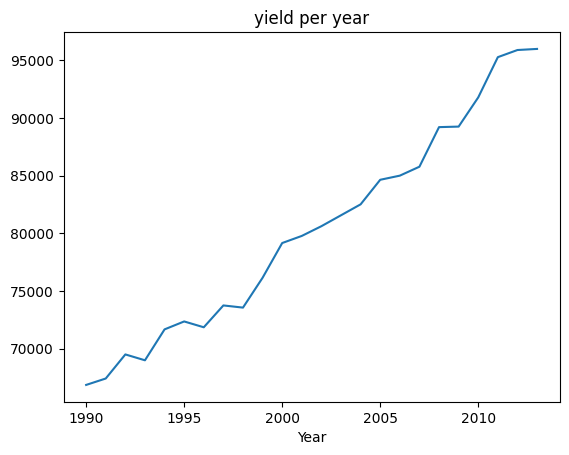

In [ ]:
temp_crop.groupby("Year")["hg/ha_yield"].mean().plot()
plt.title("yield per year")
plt.show()

In [ ]:
temp_crop.groupby("hg/ha_yield")["average_rain_fall_mm_per_year"].mean()

,average_rain_fall_mm_per_year
hg/ha_yield,
50,691.0
80,691.0
100,691.0
111,691.0
112,691.0
...,...
484810,1732.0
487219,1537.0
490361,1732.0


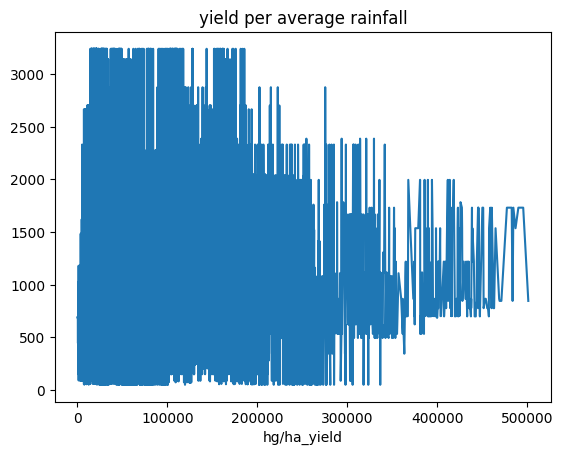

In [ ]:
temp_crop.groupby("hg/ha_yield")["average_rain_fall_mm_per_year"].mean().plot()
plt.title("yield per average rainfall")
plt.show()

In [ ]:
temp_crop.groupby("Year")["avg_temp_y"].mean()

,avg_temp_y
Year,
1990,22.867444
1991,22.820249
1992,22.630747
1993,22.803841
1994,22.815162
1995,22.879162
1996,22.718940
1997,22.591893
1998,23.185644


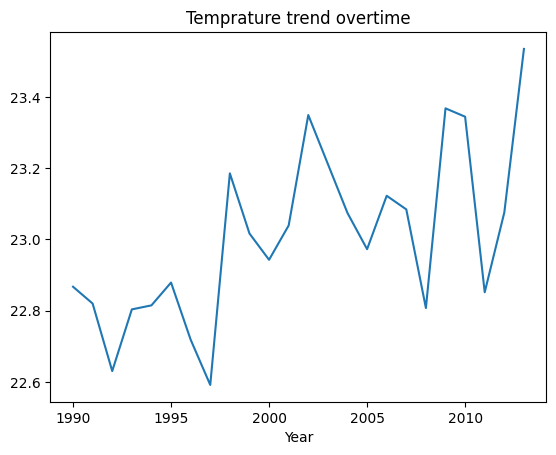

In [ ]:
#Time based pattern
temp_crop.groupby("Year")["avg_temp_y"].mean().plot()
plt.title("Temprature trend overtime")
plt.show()

In [ ]:
#correlation
#show relationship between yield and climate
temp_crop.corr(numeric_only=True)

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp_x,avg_temp_y,Yield per pesticide,Yield per rainfall
Unnamed: 0,1.000000,0.119094,0.014818,-0.402596,-0.472183,-0.043916,-0.043937,0.026712,0.056181
Year,0.119094,1.000000,0.103172,-0.001631,0.147673,0.030076,0.030076,0.017963,0.049411
hg/ha_yield,0.014818,0.103172,1.000000,0.010151,0.020979,-0.073112,-0.073112,0.013451,0.463322
average_rain_fall_mm_per_year,-0.402596,-0.001631,0.010151,1.000000,0.353187,0.200786,0.200786,-0.027130,-0.246037
pesticides_tonnes,-0.472183,0.147673,0.020979,0.353187,1.000000,-0.001809,-0.001809,-0.028725,-0.096894
avg_temp_x,-0.043916,0.030076,-0.073112,0.200786,-0.001809,1.000000,0.858546,0.004709,-0.085569
avg_temp_y,-0.043937,0.030076,-0.073112,0.200786,-0.001809,0.858546,1.000000,0.004709,-0.085569
Yield per pesticide,0.026712,0.017963,0.013451,-0.027130,-0.028725,0.004709,0.004709,1.000000,0.023298
Yield per rainfall,0.056181,0.049411,0.463322,-0.246037,-0.096894,-0.085569,-0.085569,0.023298,1.000000


In [ ]:
#crosstab
#categorical relationship(cropvsyear)
pd.crosstab(temp_crop["Item"],temp_crop["Year"])

Year,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
Item,,,,,,,,,,,,,,,,,,,,,
Cassava,758,758,759,759,759,759,759,759,759,759,...,759,759,759,759,759,759,759,759,759,759
Maize,1059,1059,1072,1073,1073,1073,1073,1073,1073,1073,...,1074,1074,1075,1075,1075,1075,1076,1076,1080,1080
Plantains and others,34,34,34,34,34,34,34,34,34,34,...,34,34,34,34,34,34,35,35,35,35
Potatoes,1084,1084,1098,1099,1099,1099,1099,1099,1099,1099,...,1102,1102,1103,1103,1103,1103,1103,1103,1107,1107
"Rice, paddy",996,996,1003,1002,1001,1001,1001,1001,1001,1001,...,1001,1001,1001,1001,1002,1002,1002,1002,1006,1006
Sorghum,896,896,904,904,903,904,904,904,904,903,...,929,929,930,929,930,929,930,930,935,935
Soybeans,1014,1013,1022,1023,1023,1023,1023,1023,1023,1023,...,1017,1020,1030,1030,1030,1030,1030,1030,1030,1029
Sweet potatoes,951,951,952,953,953,953,953,954,954,954,...,954,954,954,954,954,954,954,954,958,958
Wheat,1035,1035,1049,1050,1050,1050,1050,1050,1050,1050,...,1051,1051,1052,1052,1052,1051,1051,1051,1055,1055


In [ ]:
#Ratio
#derived metrics=higher marks
temp_crop["Yield per pesticide"]=(temp_crop["hg/ha_yield"]/temp_crop["pesticides_tonnes"])

In [ ]:
temp_crop["Yield per rainfall"]=(temp_crop["hg/ha_yield"]/temp_crop["average_rain_fall_mm_per_year"])

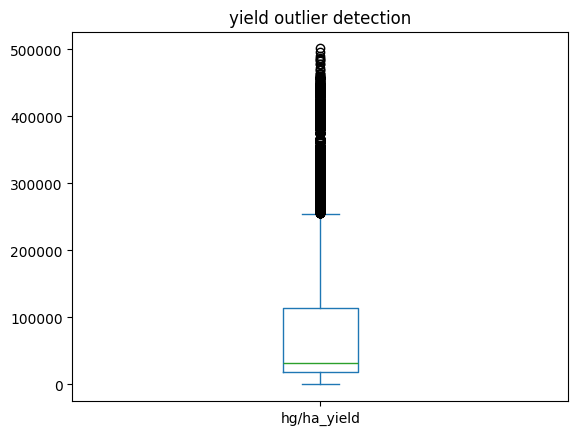

In [ ]:
#outlier
temp_crop["hg/ha_yield"].plot(kind="box")
plt.title("yield outlier detection")
plt.show()

In [ ]:
temp_crop[
temp_crop["hg/ha_yield"] >
temp_crop["hg/ha_yield"].quantile(0.95)
]

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp_x,avg_temp_y,Yield per pesticide,Yield per rainfall
194,194,Algeria,Potatoes,2010,270526,89.0,1295.88,17.59,17.59,208.758527,3039.617978
199,199,Algeria,Potatoes,2011,292806,89.0,13861.76,17.79,17.79,21.123292,3289.955056
204,204,Algeria,Potatoes,2012,304291,89.0,17379.76,17.91,17.91,17.508355,3419.000000
209,209,Algeria,Potatoes,2013,303218,89.0,17278.65,17.65,17.65,17.548709,3406.943820
545,461,Argentina,Potatoes,1995,274272,591.0,37842.00,17.74,17.74,7.247820,464.081218
...,...,...,...,...,...,...,...,...,...,...,...
185535,27707,United Kingdom,Potatoes,2013,408993,1220.0,17673.46,9.91,8.76,23.141649,335.240164
185536,27707,United Kingdom,Potatoes,2013,408993,1220.0,17673.46,9.91,9.57,23.141649,335.240164
185537,27707,United Kingdom,Potatoes,2013,408993,1220.0,17673.46,9.91,9.57,23.141649,335.240164
185538,27707,United Kingdom,Potatoes,2013,408993,1220.0,17673.46,9.91,8.39,23.141649,335.240164


In [ ]:
#multi dimensional analysis
temp_crop.groupby(["Year","Item"])["hg/ha_yield"].mean()

Year  Item                
1990  Cassava                 168713.069921
      Maize                    21897.441926
      Plantains and others    106608.382353
      Potatoes                170416.139299
      Rice, paddy              31502.643574
                                  ...      
2013  Sorghum                  16071.318717
      Soybeans                 15564.939747
      Sweet potatoes          127581.940501
      Wheat                    33512.640758
      Yams                    119994.551351
Name: hg/ha_yield, Length: 230, dtype: float64